# SSD 配對交易系統：各階段運作邏輯解析

本系統採用滾動回測架構，將配對交易的完整流程劃分為三個主要階段：
**形成期 (Formation)**、**交易期 (Trading)** 與 **績效評估 (Performance)**。

本文件詳細記錄了「SSD (最小殘差平方和) 配對交易滾動回測系統」中四大核心模組的運作邏輯與數學公式。系統採用滾動視窗 (Rolling Window) 框架，有效隔離「形成期」與「交易期」，以避免未來數據偏差 (Look-ahead Bias)。

  <div style="display: flex; justify-content: center; width: 100%;">
    <img src="..\svg\ssd_pairs_trading_architecture.svg" style="width: 90vw; max-width: 1000px; height: auto;">
  </div>

In [1]:
"""
SSD 配對交易滾動回測系統 (多參數網格搜索版)
核心功能：基於 SSD 與 Z-Score 的配對交易回測，支援多參數網格搜索與績效視覺化。
"""

import sqlite3
import warnings
import itertools
import os
from datetime import datetime
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns 

warnings.filterwarnings("ignore")

# Formation 形成期

<div style="display: flex; justify-content: center; width: 100%;">
   <img src="..\svg\stage1_formation.svg" style="width: 90vw; max-width: 1000px; height: auto;">
</div>

## 1. 價格對數化與標準化 (Log-Transformation & Standardization)

對於標的 $i$，其在時間 $t$ 的處理公式為：

1. **取對數 (Log Price)**：
   $$Log\_P_i(t) = \ln(P_i(t))$$

2. **計算對數均值與標準差**：
   $$\mu_{\ln, i} = Average(Log\_P_i)$$
   $$\sigma_{\ln, i} = StandardDeviation(Log\_P_i)$$

3. **Z-Score 標準化**：
   $$Norm\_P_i(t) = \frac{Log\_P_i(t) - \mu_{\ln, i}}{\sigma_{\ln, i}}$$

## 2. 產業板塊配對限制 (Sector-Aware Pairing)

系統透過外部傳入的 `sector_mapping` 字典，將股票依照產業分組 (Sector Groups)。

* **排除未知產業**：捨棄被標記為 `"Unknown"` 的股票，不參與配對。
* **最低成對門檻**：若該產業內的股票數量少於 `MIN_TICKERS_FOR_PAIRING` (預設為 2)，則跳過該產業。
* **組內兩兩配對**：僅使用 `itertools.combinations(sector_tickers, 2)` 對**同產業內**的標的產生兩兩組合，這大幅減少了不合理的計算量，提升共整合機率。

## 3. 向量化 OLS 迴歸與參數求解 (Vectorized OLS Regression)

設標的 B 的標準化陣列為 $X$，標的 A 的標準化陣列為 $Y$。

1. **計算共變異數矩陣**：
   $$Cov\_Matrix = \begin{bmatrix} Var(X) & Cov(X, Y) \\ Cov(X, Y) & Var(Y) \end{bmatrix}$$

2. **求解避險比例 $\beta$ (斜率)**：
   若 $Var(X) > 10^{-8}$ (避免除以零的浮點數溢位錯誤)：
   $$\beta = \frac{Cov(X, Y)}{Var(X)}$$
   否則 $\beta = 0.0$

3. **求解截距項 $\alpha$**：
   $$\alpha = \bar{Y} - \beta \cdot \bar{X}$$
   (其中 $\bar{Y}$ 與 $\bar{X}$ 為該對數標準化序列的平均值，理論上趨近於 0)

## 4. 最小殘差平方和 (SSD) 與形成期價差波動率

1. **計算歷史殘差 (Residuals)**：
   $$Residual(t) = Y(t) - (\alpha + \beta \cdot X(t))$$

2. **計算最小殘差平方和 (SSD)**：
   $$SSD = \sum_{t=1}^{T} Residual(t)^2$$

3. **計算形成期價差 (Formation Spread) 及其標準差**：
   定義未加入截距項的純價差為：
   $$Form\_Spread(t) = Y(t) - \beta \cdot X(t)$$
   計算其樣本標準差 (即程式碼中的 `form_spread_std`，使用自由度 $ddof=1$)：
   $$Form\_Spread\_Std = \sqrt{\frac{\sum (Form\_Spread(t) - \overline{Form\_Spread})^2}{T-1}}$$

## 5. 最佳配對選拔與參數凍結 (Pair Selection & Output)

系統選取全市場或各板塊 $SSD$ 最小的前 $N$ 組配對 (`top_n`)。

為了避免未來數據偏差 (Look-ahead bias)，系統會嚴格凍結並儲存以下**形成期參數**供交易期使用：
* `Log_Mean_A`, `Log_Std_A` (標的 A 的對數均值與標準差)
* `Log_Mean_B`, `Log_Std_B` (標的 B 的對數均值與標準差)
* `Hedge_Ratio` (避險比例 $\beta$)
* `Form_Spread_Std` (形成期價差標準差)

最終輸出一個包含 `Form_Start`, `Form_End` 與上述參數的 DataFrame `selected_pairs`，確保交易模組能精準對接。

In [2]:

# ══════════════════════════════════════════════════════════════════════════════
# 全局類別常數
# ══════════════════════════════════════════════════════════════════════════════
MIN_TICKERS_FOR_PAIRING = 2  
ZSCORE_CLIP = 10.0           
MIN_SPREAD_STD = 1e-6        

# ══════════════════════════════════════════════════════════════════════════════
# Class 1：Formation（形成期模組）
# ══════════════════════════════════════════════════════════════════════════════
class Formation:
    def __init__(self, price_df: pd.DataFrame, form_start: str, form_end: str, top_n: int = 20, sector_mapping: dict = None):
        self.price_df = price_df.copy()
        self.form_start = form_start  
        self.form_end = form_end      
        self.top_n = top_n
        self.sector_mapping = sector_mapping or {}

        self.normalized_df: pd.DataFrame = pd.DataFrame()
        self.ssd_records: list = []
        self.selected_pairs: pd.DataFrame = pd.DataFrame()

    def normalize_prices(self) -> pd.DataFrame:
        log_prices = np.log(self.price_df)
        self.mean_prices = log_prices.mean()
        self.std_prices = log_prices.std()
        self.normalized_df = (log_prices - self.mean_prices) / self.std_prices
        return self.normalized_df

    def compute_ssd(self) -> pd.DataFrame:
        if self.normalized_df.empty:
            self.normalize_prices()

        tickers = self.normalized_df.columns.tolist()
        self.ssd_records = []

        sector_groups = {}
        if self.sector_mapping:
            for ticker in tickers:
                sector = self.sector_mapping.get(ticker, "Unknown")
                sector_groups.setdefault(sector, []).append(ticker)
        else:
            sector_groups["All_Market"] = tickers

        skipped_unknown_count = 0
        for sector, sector_tickers in sector_groups.items():
            if sector == "Unknown": 
                skipped_unknown_count = len(sector_tickers)
                continue 
            
            if len(sector_tickers) < MIN_TICKERS_FOR_PAIRING: continue
                
            for ticker_a, ticker_b in itertools.combinations(sector_tickers, 2):
                y_val = self.normalized_df[ticker_a].values
                x_val = self.normalized_df[ticker_b].values
                
                # 向量化求 OLS 解析解
                cov_matrix = np.cov(x_val, y_val)
                var_x = cov_matrix[0, 0]
                cov_xy = cov_matrix[0, 1]
                
                beta = cov_xy / var_x if var_x > 1e-8 else 0.0
                alpha = np.mean(y_val) - beta * np.mean(x_val)
                
                residuals = y_val - (alpha + beta * x_val)
                ssd_value = np.sum(residuals ** 2)
                
                form_spread = y_val - beta * x_val
                form_spread_std = np.std(form_spread, ddof=1) if len(form_spread) > 1 else 0.0
                
                self.ssd_records.append({
                    "Form_Start": self.form_start, "Form_End": self.form_end, 
                    "Sector": sector, "Ticker_A": ticker_a, "Ticker_B": ticker_b,
                    "SSD": round(ssd_value, 6), "Hedge_Ratio": round(beta, 4),
                    "Form_Spread_Std": round(form_spread_std, 6)
                })

        # if skipped_unknown_count > 0:
        #     print(f"  [Formation] 跳過 {skipped_unknown_count} 支未分類 (Unknown) 股票。")

        if not self.ssd_records: return pd.DataFrame()
        return pd.DataFrame(self.ssd_records).sort_values("SSD").reset_index(drop=True)

    def select_pairs(self) -> pd.DataFrame:
        ssd_df = self.compute_ssd()
        if ssd_df.empty:
            self.selected_pairs = pd.DataFrame()
            return self.selected_pairs

        selected = ssd_df.head(self.top_n).copy()
        selected["Rank"] = range(1, len(selected) + 1)

        mean_a_list, std_a_list, mean_b_list, std_b_list = [], [], [], []
        for _, row in selected.iterrows():
            mean_a_list.append(self.mean_prices[row["Ticker_A"]])
            std_a_list.append(self.std_prices[row["Ticker_A"]])
            mean_b_list.append(self.mean_prices[row["Ticker_B"]])
            std_b_list.append(self.std_prices[row["Ticker_B"]])
            
        selected["Log_Mean_A"] = mean_a_list
        selected["Log_Std_A"] = std_a_list
        selected["Log_Mean_B"] = mean_b_list
        selected["Log_Std_B"] = std_b_list

        self.selected_pairs = selected
        return self.selected_pairs

    def run(self) -> pd.DataFrame:
        self.normalize_prices()
        self.select_pairs()
        return self.selected_pairs


# Trading 交易期

<div style="display: flex; justify-content: center; width: 100%;">
   <img src="..\svg\stage2_trading.svg" style="width: 90vw; max-width: 1000px; height: auto;">
</div>

## 1. 樣本外標準化與靜態 Z-Score 計算

對於交易期 $t$ 的每日最新價格 $P'_A(t)$ 與 $P'_B(t)$：

1. **對數轉換與樣本外標準化**：
   $$Norm\_P'_A(t) = \frac{\ln(P'_A(t)) - \mu_{\ln, A}}{\sigma_{\ln, A}}$$
   $$Norm\_P'_B(t) = \frac{\ln(P'_B(t)) - \mu_{\ln, B}}{\sigma_{\ln, B}}$$
   *(其中 $\mu, \sigma$ 皆為形成期的對數均值與標準差)*

2. **價差 (Spread) 計算**：
   $$Spread(t) = Norm\_P'_A(t) - \beta \cdot Norm\_P'_B(t)$$

3. **靜態 Z-Score 計算與極值限制**：
   直接除以**形成期的價差標準差 (Form_Spread_Std)**，真實反映當下價差相較於歷史常態的偏離程度。
   $$Z(t) = \text{Clip}\left( \frac{Spread(t)}{\max(Form\_Spread\_Std, 10^{-6})}, -10, 10 \right)$$
   *(設定最小值 $10^{-6}$ 避免除以零，並將 Z-Score 截斷在 $\pm10$ 避免極端跳空導致程式錯誤)*

## 2. 進場邏輯與風險中立資金分配

1. **波動率倒數權重**：
   $$W_A = \frac{1}{\sigma_{\ln, A}}, \quad W_B = \frac{1}{\sigma_{\ln, B}}$$

2. **基準資金乘數 ($M$)**：
   $$M = \frac{Capital_{pair}}{W_A + W_B}$$

3. **建倉股數計算 (Shares)**：
   * **做空價差 (Short Spread, $Z > Entry\_Z$)**：放空 A、做多 B
     $$Shares_A = -\frac{M \cdot W_A}{P'_A(t)}, \quad Shares_B = \frac{M \cdot W_B \cdot \beta}{P'_B(t)}$$
   * **做多價差 (Long Spread, $Z < -Entry\_Z$)**：做多 A、放空 B
     $$Shares_A = \frac{M \cdot W_A}{P'_A(t)}, \quad Shares_B = -\frac{M \cdot W_B \cdot \beta}{P'_B(t)}$$

4. **進場摩擦成本 (Trade Entry Fee)**：
   包含手續費 (Fee) 與滑價 (Slippage)，以絕對成交金額乘以總摩擦費率計算。
   $$Entry\_Fee = \left( |Shares_A| \cdot P'_A(t) + |Shares_B| \cdot P'_B(t) \right) \cdot (Fee\_Rate + Slippage\_Rate)$$

## 3. 出場與停損結算

1. **單筆交易損益結算 (Trade PnL)**：
   $$Unrealized = Shares_A \cdot (P'_A(t) - Entry\_P_A) + Shares_B \cdot (P'_B(t) - Entry\_P_B)$$
   $$Exit\_Fee = \left( |Shares_A| \cdot P'_A(t) + |Shares_B| \cdot P'_B(t) \right) \cdot (Fee\_Rate + Slippage\_Rate)$$
   $$Trade\_PnL = Unrealized - Entry\_Fee - Exit\_Fee$$

2. **出場條件 (Exit)**：
   * 做空價差：當 $Z \le Exit\_Z$ 時平倉。
   * 做多價差：當 $Z \ge -Exit\_Z$ 時平倉。

3. **停損機制 (Stop Loss)**：
   若單筆交易的帳面虧損佔配對本金的比例達到閾值，立即強平。
   $$\text{If } \frac{-Trade\_PnL}{Capital_{pair}} \ge Stop\_Loss\_Pct \rightarrow \text{Trigger Stop Loss}$$

## 4. 冷卻期 (Cooldown) 與連續進場控制

1. **狀態鎖定**：若 `allow_reentry = False`，停損後鎖死該配對，本期不再交易 (`is_stopped = True`)。
2. **冷卻期鎖定**：平倉或停損後，紀錄上一筆交易方向 (`cooldown_dir = position`)，**禁止在同一方向立即重新建倉**。
3. **解除冷卻**：必須等到 Z-Score 真正回歸並穿越另一側出場線，才能解除冷卻，允許下一次進場：
   * 原做空價差 (`cooldown_dir = -1`)：需等 $Z \le Exit\_Z$ 才能解除。
   * 原做多價差 (`cooldown_dir = 1`)：需等 $Z \ge -Exit\_Z$ 才能解除。

## 5. 單日損益增量 (Daily Delta) 追蹤

為了在多個交易視窗重疊時，能夠正確將總損益拼接到一條連續的資金曲線上，每個配對每天都會計算 `Daily_Delta`：
$$Daily\_Delta(t) = Cumulative\_PnL(t) - Cumulative\_PnL(t-1)$$
這樣 Performance 模組只需將同日所有配對的 `Daily_Delta` 相加，即可得到完美無偏差的全策略單日淨值變動。

## 6. 全域資金管理與動態分配機制 (Global Capital Management)

<div style="display: flex; justify-content: center; width: 100%;">
   <img src="..\svg\stage3_capital_allocation.svg" style="width: 90vw; max-width: 1000px; height: auto;">
</div>

### 6.1 獨立資金槽與動態複利 (Capital Slots & Compounding)
在滾動視窗設計中，由於交易期（Trading Window）通常大於滾動步距（Rolling Step），同一時間點市場上會有多個交易期正在並行。
1. **資金切割**：系統將總初始本金 ($Capital_{initial}$) 嚴格切分為 $K$ 個獨立的資金槽（Slots），其中 $K = TRADING\_WINDOW \div ROLLING\_STEP$。
2. **對號入座與獨立複利**：每個交易期啟動時，會尋找當下閒置的資金槽。該期結束後，結算的總損益 (PnL) 會全數滾入該槽內。這保證了各期資金互不挪用、槓桿不失控，且自動實現了獨立的動態複利。
   $$Slot\_Capital_k(T+1) = \max(0, Slot\_Capital_k(T) + Period\_PnL)$$

### 6.2 風險中立的配對資金分配 (Risk-Neutral Allocation)
進入單一配對的具體下單邏輯時，系統揚棄了傳統的「資金各半」策略，改以形成期的對數波動率進行反向加權，確保多空雙邊在價格震盪時的風險曝險是相等的。
1. **單組預算上限**：該期取用的資金槽總額，將平均分配給當期的 $N$ 組配對。
   $$Capital_{pair} = \frac{Slot\_Capital_k}{TOP\_N\_PAIRS}$$
2. **波動率反向加權**：
   以標的 A 與 B 的歷史標準差倒數作為權重基礎：
   $$W_A = \frac{1}{\sigma_{\ln, A}}, \quad W_B = \frac{1}{\sigma_{\ln, B}}$$
   接著計算基準資金乘數 $M$，確保雙邊總動用資金不超過 $Capital_{pair}$：
   $$M = \frac{Capital_{pair}}{W_A + W_B}$$
3. **最終股數決定 (Shares)**：
   當觸發做空價差 (放空 A 並做多 B) 時，系統將按照以下公式計算精確股數（已包含避險比例 $\beta$ 調整）：
   $$Shares_A = -\frac{M \cdot W_A}{P'_A(t)}, \quad Shares_B = \frac{M \cdot W_B \cdot \beta}{P'_B(t)}$$
   此設計讓價格波動劇烈的高風險標的獲配較少資金，走勢平穩的標的獲配較多資金，達到真正的市場中立性。

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Class 2：Trading（交易期模組）
# ══════════════════════════════════════════════════════════════════════════════
@dataclass
class PairState:
    """單一配對在模擬過程中的內部狀態"""
    position: int = 0
    shares_a: float = 0.0
    shares_b: float = 0.0
    entry_price_a: float = 0.0
    entry_price_b: float = 0.0
    realized_pnl: float = 0.0
    trade_entry_fee: float = 0.0
    days_held: int = 0
    is_stopped: bool = False
    cooldown_dir: int = 0
    prev_total_pnl: float = 0.0

class Trading:
    def __init__(self, price_df: pd.DataFrame, selected_pairs: pd.DataFrame, capital_per_pair: float, 
                 fee_rate: float, slippage_rate: float, stop_loss_pct: float, entry_z: float, exit_z: float, allow_reentry: bool = False):
        self.price_df = price_df.copy()
        self.selected_pairs = selected_pairs
        self.capital_per_pair = capital_per_pair
        
        self.friction_rate = fee_rate + slippage_rate
        self.stop_loss_pct = stop_loss_pct
        self.entry_z = entry_z
        self.exit_z  = exit_z
        self.allow_reentry = allow_reentry  
        self.all_trade_logs: list = []
        self.period_pnl: float = 0.0

    def _execute_entry(self, state: PairState, z: float, p_a: float, p_b: float, log_std_a: float, log_std_b: float, hedge_ratio: float) -> tuple[bool, float]:
        """處理進場邏輯與資金分配"""
        weight_a = 1.0 / log_std_a
        weight_b = 1.0 / log_std_b
        M = self.capital_per_pair / (weight_a + weight_b)
        
        if z > self.entry_z and state.cooldown_dir != -1:
            state.position = -1
            state.shares_a = -(M * weight_a) / p_a
            state.shares_b = (M * weight_b * hedge_ratio) / p_b
        elif z < -self.entry_z and state.cooldown_dir != 1:
            state.position = +1
            state.shares_a = (M * weight_a) / p_a
            state.shares_b = -(M * weight_b * hedge_ratio) / p_b
        else:
            return False, 0.0

        state.entry_price_a = p_a
        state.entry_price_b = p_b
        state.trade_entry_fee = (abs(state.shares_a) * p_a + abs(state.shares_b) * p_b) * self.friction_rate
        state.days_held = 0
        return True, -state.trade_entry_fee

    def _execute_close(self, state: PairState, current_trade_pnl: float, stop_loss: bool = False):
        """處理平倉與停損邏輯"""
        state.realized_pnl += current_trade_pnl 
        
        if stop_loss and not self.allow_reentry:
            state.is_stopped = True
        else:
            if self.allow_reentry:
                state.cooldown_dir = state.position  
                
        state.position = 0

    def _simulate_pair(self, sector: str, ticker_a: str, ticker_b: str, pair_rank: int, hedge_ratio: float, 
                       form_spread_std: float, log_mean_a: float, log_std_a: float, log_mean_b: float, log_std_b: float) -> list:
        if ticker_a not in self.price_df.columns or ticker_b not in self.price_df.columns: return []

        price_a, price_b = self.price_df[ticker_a].dropna(), self.price_df[ticker_b].dropna()
        common_idx = price_a.index.intersection(price_b.index)
        price_a, price_b = price_a.loc[common_idx], price_b.loc[common_idx]

        if len(price_a) < 5: return []

        log_p_a = np.log(price_a)
        log_p_b = np.log(price_b)

        norm_p_a = (log_p_a - log_mean_a) / log_std_a
        norm_p_b = (log_p_b - log_mean_b) / log_std_b
        
        spread = norm_p_a - hedge_ratio * norm_p_b
        
        safe_std = max(form_spread_std, MIN_SPREAD_STD)
        zscore = np.clip(spread / safe_std, -ZSCORE_CLIP, ZSCORE_CLIP)

        dates_arr = common_idx
        zscore_arr = zscore.values
        pa_arr = price_a.values
        pb_arr = price_b.values

        # 預建靜態常數字典
        base_log = {
            "Sector": sector, "Pair_Rank": pair_rank,
            "Ticker_A": ticker_a, "Ticker_B": ticker_b,
            "Hedge_Ratio": round(float(hedge_ratio), 4),
            "Log_Mean_A": log_mean_a, "Log_Std_A": log_std_a,
            "Log_Mean_B": log_mean_b, "Log_Std_B": log_std_b
        }

        state = PairState()
        daily_logs = []

        for i in range(len(dates_arr)):
            date = dates_arr[i]
            z = 0.0 if np.isnan(zscore_arr[i]) else zscore_arr[i]
            p_a, p_b = pa_arr[i], pb_arr[i]

            unrealized_pnl = 0.0
            closed_trade_pnl = 0.0 
            daily_delta = 0.0
            current_status = "HOLD_CASH"

            if state.is_stopped:
                current_status = "STOPPED"
                log_record = base_log.copy()
                log_record.update({
                    "Date": date, "Price_A": round(p_a, 4), "Price_B": round(p_b, 4), "ZScore": round(float(z), 4),
                    "Position": 0, "Unrealized_PnL": 0.0, "Realized_PnL": round(float(state.realized_pnl), 4), 
                    "Cumulative_PnL": round(float(state.realized_pnl), 4), "Status": current_status, 
                    "Trade_PnL": 0.0, "Days_Held": 0, "Daily_Delta": 0.0
                })
                daily_logs.append(log_record)
                continue

            # 穿越邊界以解除冷卻
            if state.cooldown_dir == -1 and z <= self.exit_z:
                state.cooldown_dir = 0
            elif state.cooldown_dir == 1 and z >= -self.exit_z:
                state.cooldown_dir = 0

            if state.position != 0:
                state.days_held += 1
                raw_unrealized = state.shares_a * (p_a - state.entry_price_a) + state.shares_b * (p_b - state.entry_price_b)
                exit_fee_est = (abs(state.shares_a)*p_a + abs(state.shares_b)*p_b) * self.friction_rate
                
                # 結算單筆完整損益
                current_trade_pnl = raw_unrealized - state.trade_entry_fee - exit_fee_est
                
                if (-current_trade_pnl / self.capital_per_pair) >= self.stop_loss_pct:
                    self._execute_close(state, current_trade_pnl, stop_loss=True)
                    closed_trade_pnl = current_trade_pnl
                    current_status = "STOP_LOSS_TRIGGERED"
                else:
                    is_exit_short = (state.position == -1) and (z <= self.exit_z)  
                    is_exit_long  = (state.position == 1)  and (z >= -self.exit_z)  
                    
                    if is_exit_short or is_exit_long:
                        self._execute_close(state, current_trade_pnl, stop_loss=False)
                        closed_trade_pnl = current_trade_pnl
                        current_status = "EXIT"
                    else:
                        unrealized_pnl = raw_unrealized - state.trade_entry_fee 
                        current_status = "HOLDING"
            else: 
                if abs(z) > self.entry_z:
                    entered, unrealized_pnl = self._execute_entry(state, z, p_a, p_b, log_std_a, log_std_b, hedge_ratio)
                    if entered:
                        current_status = "ENTER_SHORT_A" if state.position == -1 else "ENTER_LONG_A"
                    else:
                        current_status = "HOLD_CASH (COOLDOWN)"
                else:
                    current_status = "HOLD_CASH"

            cumulative_pnl = state.realized_pnl + unrealized_pnl
            daily_delta = cumulative_pnl - state.prev_total_pnl
            state.prev_total_pnl = cumulative_pnl
            
            log_record = base_log.copy()
            log_record.update({
                "Date": date, "Price_A": round(p_a, 4), "Price_B": round(p_b, 4), "ZScore": round(float(z), 4),
                "Position": state.position, "Unrealized_PnL": round(float(unrealized_pnl), 4),
                "Realized_PnL": round(float(state.realized_pnl), 4), "Cumulative_PnL": round(float(cumulative_pnl), 4),
                "Status": current_status, "Trade_PnL": round(float(closed_trade_pnl), 4),
                "Days_Held": state.days_held, "Daily_Delta": round(float(daily_delta), 4)
            })
            daily_logs.append(log_record)

            if current_status in ["STOP_LOSS_TRIGGERED", "EXIT"]:
                state.days_held = 0 

        # 回測期末強制平倉未結算部位
        if state.position != 0 and daily_logs:
            last_status = daily_logs[-1]["Status"]
            if last_status not in ("EXIT", "STOP_LOSS_TRIGGERED", "PERIOD_END_EXIT", "STOPPED"):
                pnl_before_last_day = daily_logs[-2]["Cumulative_PnL"] if len(daily_logs) > 1 else 0.0
                
                p_a_last, p_b_last = pa_arr[-1], pb_arr[-1]
                raw_unrealized_final = state.shares_a * (p_a_last - state.entry_price_a) + state.shares_b * (p_b_last - state.entry_price_b)
                exit_fee = (abs(state.shares_a)*p_a_last + abs(state.shares_b)*p_b_last) * self.friction_rate
                
                closed_trade_pnl = raw_unrealized_final - state.trade_entry_fee - exit_fee
                state.realized_pnl += closed_trade_pnl
                daily_delta = state.realized_pnl - pnl_before_last_day 
                
                daily_logs[-1].update({
                    "Status": "PERIOD_END_EXIT", 
                    "Realized_PnL": round(state.realized_pnl, 4), 
                    "Cumulative_PnL": round(state.realized_pnl, 4), 
                    "Unrealized_PnL": 0.0,
                    "Trade_PnL": round(closed_trade_pnl, 4),
                    "Daily_Delta": round(daily_delta, 4),
                    "Days_Held": state.days_held
                })

        return daily_logs

    def run(self) -> tuple:
        self.all_trade_logs = []
        for _, row in self.selected_pairs.iterrows():
            logs = self._simulate_pair(
                row.get("Sector", "Unknown"), row["Ticker_A"], row["Ticker_B"], row["Rank"], float(row.get("Hedge_Ratio", 1.0)), 
                float(row.get("Form_Spread_Std", 1.0)), float(row.get("Log_Mean_A", 0.0)), float(row.get("Log_Std_A", 1.0)), 
                float(row.get("Log_Mean_B", 0.0)), float(row.get("Log_Std_B", 1.0))
            )
            self.all_trade_logs.extend(logs)
            
        if not self.all_trade_logs: 
            return pd.DataFrame(), pd.Series(dtype=float)
            
        log_df = pd.DataFrame(self.all_trade_logs)
        period_daily_delta = log_df.groupby("Date")["Daily_Delta"].sum()
        
        self.period_pnl = float(period_daily_delta.sum()) if not period_daily_delta.empty else 0.0
        
        return log_df, period_daily_delta


# Performance 績效評估

<div style="display: flex; justify-content: center; width: 100%;">
   <img src="..\svg\stage4_performance.svg" style="width: 90vw; max-width: 1000px; height: auto;">
</div>


## 1. 全域單日損益疊加與淨值曲線 (Global Daily Delta & Equity Curve)

1. **全域單日損益疊加 ($Global\_\Delta$)**：
   將當期所有配對的每日損益增量，按日期對齊並累加到全域時間軸中：
   $$Global\_\Delta(t) = \sum_{p \in Active\_Periods} Daily\_Delta_{p}(t)$$

2. **資金淨值曲線 (Equity Curve)**：
   全策略的每日總淨值，即為初始本金加上歷史至今的每日損益增量累加值：
   $$Equity(t) = Capital_{initial} + \sum_{k=1}^{t} Global\_\Delta(k)$$

## 2. 單日報酬率與總體風險報酬指標 (Overall Metrics)

1. **嚴格的單日報酬率 (Daily Return)**：
   使用當日 Delta 除以「昨日淨值」來計算真實日報酬率，公式推導如下：
   $$R_{daily}(t) = \frac{Global\_\Delta(t)}{Equity(t) - Global\_\Delta(t)} = \frac{Equity(t) - Equity(t-1)}{Equity(t-1)}$$

2. **年化報酬率 (Annualized Return, $R_{ann}$)**：
   $$R_{ann} = \left( \frac{Equity_{final}}{Capital_{initial}} \right)^{\frac{252}{Total\_Trading\_Days}} - 1$$

3. **夏普比率 (Sharpe Ratio)**：
   *(假設無風險利率 $R_f = 0$)*
   $$Sharpe = \frac{R_{ann}}{\sigma(R_{daily}) \cdot \sqrt{252}}$$

4. **最大回撤 (Maximum Drawdown, MDD)**：
   淨值從歷史最高點回落的最大幅度：
   $$MDD = \min_{t} \left( \frac{Equity(t) - \max_{k \le t} Equity(k)}{\max_{k \le t} Equity(k)} \right)$$

## 3. 雙重資本報酬率評估 (Dual Capital Returns)

1. **投入資本報酬率 (R_CC, Return on Committed Capital)**：
   基於該期被「預先匡列、鎖定」的總預備資金計算。
   $$R_{CC} = \frac{Period\_PnL}{Capital_{Deployed}} \times 100\%$$

2. **動用資本報酬率 (R_EC, Return on Employed Capital)**：
   基於該期「實際有觸發進場訊號」的配對所佔用的資金計算 ($N_{traded}$ 為實際交易配對數)。
   $$R_{EC} = \frac{Period\_PnL}{N_{traded} \times Capital_{pair}} \times 100\%$$

## 4. 交易層級統計與盈虧比 (Trade-Level Statistics)

1. **單筆交易勝率 (Trade Win Rate)**：
   $$Trade\_Win\_Rate = \frac{N_{win\_trades}}{N_{total\_trades}} \times 100\%$$

2. **盈虧比 (Payoff Ratio)**：
   總獲利金額除以總虧損金額的絕對值，衡量賺賠效率：
   $$Payoff\_Ratio = \frac{\sum (Trade\_PnL \mid Trade\_PnL > 0)}{\sum |Trade\_PnL \mid Trade\_PnL < 0|}$$

3. **平均持倉天數 (Average Holding Days)**：
   計算所有平倉部位從進場到出場的平均持有時間：
   $$Avg\_Hold\_Days = \frac{\sum Days\_Held}{N_{total\_trades}}$$

## 5. 視覺化面板與配對解剖圖 (Visualizations)

1. **四大績效儀表板 (`_plot_performance`)**：
   * **Equity Curve**：繪製總資金成長曲線。
   * **Drawdown (%)**：繪製水下淨值曲線 (Underwater Curve)，直觀顯示回撤深度與修復期。
   * **Rolling Period Returns**：使用並排長條圖 (Bar Chart) 對比各期的 $R_{CC}$ 與 $R_{EC}$。
   * **Daily Return Distribution**：繪製日報酬率的直方圖 (Histogram)，檢驗報酬分配特徵 (如偏態、厚尾)。

2. **最佳與最差配對解剖圖 (`_plot_best_worst_pairs`)**：
   系統自動抓出回測中表現「最好 (Best)」、「中位數 (Median)」、「最差 (Worst)」的配對，繪製 3x3 的矩陣圖。
   * **上層**：標的 A 與標的 B 經過 Beta 調整後的標準化對數走勢對比，並標註精確的進出場點位 (做多、做空、平倉、停損)。
   * **中層**：Z-Score 的收斂與發散走勢，對照固定的進出場閾值線 (Entry/Exit Targets)。
   * **下層**：該單一配對在持倉期間內的累積損益 (Cum PnL) 曲線。

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Class 3：Performance（績效評估模組）
# ══════════════════════════════════════════════════════════════════════════════
class Performance:
    TRADING_DAYS_PER_YEAR = 252
    def __init__(self, initial_capital: float, output_dir: Path):
        self.initial_capital = initial_capital
        self.output_dir = output_dir
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.period_summaries, self.all_period_logs = [], []
        
        self._global_daily_delta = pd.Series(dtype=float) 
        self.equity_series = pd.Series(dtype=float)
        
        plt.rcParams.update({"figure.facecolor": "#0d1117", "axes.facecolor": "#161b22", "axes.edgecolor": "#30363d", 
                             "axes.labelcolor": "#c9d1d9", "axes.titlecolor": "#f0f6fc", "xtick.color": "#8b949e", 
                             "ytick.color": "#8b949e", "text.color": "#c9d1d9"})

    def set_zscore_params(self, entry_z: float, exit_z: float):
        self._entry_z, self._exit_z = entry_z, exit_z

    def add_period(self, period_start: str, period_end: str, trade_log_df: pd.DataFrame, period_daily_delta: pd.Series, capital_deployed: float, capital_per_pair: float):
        if trade_log_df.empty or period_daily_delta.empty: return
        
        if self._global_daily_delta.empty:
            self._global_daily_delta = period_daily_delta
        else:
            self._global_daily_delta = self._global_daily_delta.add(period_daily_delta, fill_value=0.0)

        period_pnl_abs = float(period_daily_delta.sum())
        
        pair_traded = trade_log_df.groupby(["Ticker_A", "Ticker_B"])["Position"].apply(lambda x: (x != 0).any())
        n_traded, n_nominated = int(pair_traded.sum()), len(pair_traded)
        r_cc = (period_pnl_abs / capital_deployed * 100) if capital_deployed > 0 else 0.0
        r_ec = (period_pnl_abs / (n_traded * capital_per_pair) * 100) if n_traded > 0 else 0.0

        exits = trade_log_df[trade_log_df["Status"].isin(["EXIT", "STOP_LOSS_TRIGGERED", "PERIOD_END_EXIT"])]
        exits = exits[exits["Trade_PnL"] != 0] 
        trade_count = len(exits)
        win_trades = len(exits[exits["Trade_PnL"] > 0])
        gross_profit = exits[exits["Trade_PnL"] > 0]["Trade_PnL"].sum()
        gross_loss = abs(exits[exits["Trade_PnL"] < 0]["Trade_PnL"].sum())
        
        payoff_ratio = (gross_profit / gross_loss) if gross_loss > 0 else np.nan
        avg_holding_days = exits["Days_Held"].mean() if trade_count > 0 else 0.0

        log_copy = trade_log_df.copy()
        log_copy["Period_Start"], log_copy["Period_End"] = period_start, period_end
        self.all_period_logs.append(log_copy)

        self.period_summaries.append({
            "Period_Start": period_start, "Period_End": period_end, "Capital_Deployed": round(capital_deployed, 2), 
            "Period_PnL_USD": round(period_pnl_abs, 2), "R_CC_Pct": round(r_cc, 4), "R_EC_Pct": round(r_ec, 4),
            "Nominated_Pairs": n_nominated, "Traded_Pairs": n_traded,
            "Trade_Count": trade_count, "Win_Trades": win_trades, "Avg_Hold_Days": round(avg_holding_days, 1),
            "Payoff_Ratio": payoff_ratio
        })

    def _plot_summary(self, report: dict):
        fig, ax = plt.subplots(figsize=(8, 6))
        fig.patch.set_facecolor("#0d1117")
        ax.axis("off")
        
        cell_text = [[k, v] for k, v in report.items()]
        table = ax.table(cellText=cell_text, colLabels=["Metric", "Value"], loc="center", cellLoc="left")
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 2)
        
        for (row, col), cell in table.get_celld().items():
            cell.set_edgecolor("#30363d")
            if row == 0:
                cell.set_facecolor("#21262d")
                cell.set_text_props(color="#f0f6fc", weight="bold")
            else:
                cell.set_facecolor("#161b22")
                cell.set_text_props(color="#c9d1d9")
            if col == 0: cell.set_width(0.6)
            else: cell.set_width(0.4)
            
        ax.set_title("📊 Performance Summary", color="#f0f6fc", fontsize=14, fontweight="bold", pad=15)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        fig.savefig(self.output_dir / "summary_report.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        plt.close(fig)

    def generate_report(self, quiet=True) -> dict:
        if not self.period_summaries or self._global_daily_delta.empty: 
            return {}

        self._global_daily_delta.sort_index(inplace=True)
        
        self.equity_series = self.initial_capital + self._global_daily_delta.cumsum()

        final_eq = self.equity_series.iloc[-1]
        pnl_abs = final_eq - self.initial_capital
        ratio = final_eq / self.initial_capital
        ann_ret = (ratio ** (self.TRADING_DAYS_PER_YEAR / len(self.equity_series)) - 1) if ratio > 0 else -1.0
        
        daily_ret = self.equity_series.pct_change().dropna()
        sharpe = ann_ret / (daily_ret.std() * np.sqrt(self.TRADING_DAYS_PER_YEAR)) if daily_ret.std() > 0 else 0.0
        
        cummax = self.equity_series.cummax()
        mdd = ((self.equity_series - cummax) / cummax).min()
        
        df_summ = pd.DataFrame(self.period_summaries)
        
        period_win_rate = sum(1 for p in self.period_summaries if p["Period_PnL_USD"] > 0) / len(self.period_summaries)
        
        total_trades = df_summ["Trade_Count"].sum()
        total_win_trades = df_summ["Win_Trades"].sum()
        trade_win_rate = (total_win_trades / total_trades) if total_trades > 0 else 0.0
        
        valid_payoffs = df_summ["Payoff_Ratio"].dropna()
        avg_payoff = valid_payoffs.mean() if not valid_payoffs.empty else 0.0

        report = {
            "Final Equity": round(final_eq, 2), "Total PnL (%)": round(pnl_abs / self.initial_capital * 100, 2),
            "Annualized Return (%)": round(ann_ret * 100, 2), "Sharpe Ratio": round(sharpe, 2),
            "Max Drawdown (%)": round(mdd * 100, 2), "Period Win Rate (%)": round(period_win_rate * 100, 1),
            "Trade Win Rate (%)": round(trade_win_rate * 100, 1), "Total Trades": int(total_trades), 
            "Avg Payoff Ratio": round(avg_payoff, 2), "Avg R_CC (%)": round(df_summ["R_CC_Pct"].mean(), 2),
            "Avg R_EC (%)": round(df_summ["R_EC_Pct"].mean(), 2)
        }

        self._plot_summary(report)

        equity_df = self.equity_series.reset_index()
        equity_df.columns = ["Date", "Equity"]
        equity_df["Daily_Return"] = self._global_daily_delta.values / (equity_df["Equity"].values - self._global_daily_delta.values)
        equity_df["Drawdown"] = equity_df["Equity"] / equity_df["Equity"].cummax() - 1
        
        self._plot_performance(equity_df, df_summ)
        if self.all_period_logs: self._plot_best_worst_pairs()
        return report

    def _plot_performance(self, equity_df, period_df):
        fig = plt.figure(figsize=(16, 12))
        gs = GridSpec(3, 2, figure=fig, height_ratios=[2.5, 1.0, 1.5], hspace=0.25, wspace=0.25)
        ax1 = fig.add_subplot(gs[0, :])  
        ax2 = fig.add_subplot(gs[1, :], sharex=ax1) 
        ax3 = fig.add_subplot(gs[2, 0])  
        ax4 = fig.add_subplot(gs[2, 1])  

        dates, equity_val = pd.to_datetime(equity_df["Date"]), equity_df["Equity"].values
        
        ax1.plot(dates, equity_val, color="#58a6ff", linewidth=1.5, label="Equity")
        ax1.set_title("Equity Curve", color="#f0f6fc")
        ax1.set_ylabel("Equity (USD)", color="#58a6ff")
        ax1.tick_params(axis='y', labelcolor="#58a6ff")
        ax1.tick_params(axis='x', labelbottom=False) 
        ax1.legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d")

        # 設定 X 軸僅顯示年份及對齊網格線
        ax1.xaxis.set_major_locator(mdates.YearLocator())
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax1.grid(axis='x', linestyle='--', alpha=0.3, color='#8b949e')

        drawdown = equity_df["Drawdown"].values * 100
        ax2.fill_between(dates, drawdown, 0, color="#da3633", alpha=0.6, label="Drawdown (%)")
        ax2.plot(dates, drawdown, color="#da3633", linewidth=0.8)
        ax2.set_ylabel("MDD (%)", color="#da3633")
        ax2.tick_params(axis='y', labelcolor="#da3633")
        ax2.legend(loc="lower left", facecolor="#161b22", edgecolor="#30363d")

        ax2.tick_params(axis='x', labelcolor="#8b949e", rotation=0)
        ax2.grid(axis='x', linestyle='--', alpha=0.3, color='#8b949e')

        if not period_df.empty:
            x, w = np.arange(len(period_df)), 0.35
            ax3.bar(x - w/2, period_df["R_CC_Pct"].values, w, label="R_CC (Committed)", color="#58a6ff", alpha=0.85)
            ax3.bar(x + w/2, period_df["R_EC_Pct"].values, w, label="R_EC (Employed)", color="#ffa657", alpha=0.85)
            ax3.set_xticks(x); ax3.set_xticklabels([f"P{i+1}" for i in range(len(period_df))], fontsize=7)
            ax3.axhline(0, color="#8b949e", linewidth=0.7)
            ax3.set_title("Return per Rolling Period (%)", color="#f0f6fc")
            ax3.legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d", fontsize=9)

        daily_ret = equity_df["Daily_Return"].dropna().values * 100
        ax4.hist(daily_ret, bins=50, color="#58a6ff", alpha=0.85)
        ax4.set_title("Daily Return Distribution (%)", color="#f0f6fc")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        fig.savefig(self.output_dir / "performance_chart.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        plt.close(fig)

    def _plot_best_worst_pairs(self):
        full_log = pd.concat(self.all_period_logs, ignore_index=True)
        pair_perf = full_log.sort_values("Date").groupby(
            ["Ticker_A", "Ticker_B", "Period_Start"]
        )["Realized_PnL"].last().reset_index(name="Final_PnL")
        
        pair_perf = pair_perf.sort_values("Final_PnL")
        if len(pair_perf) < 3: return
        
        targets = [("Best", pair_perf.iloc[-1]), ("Median", pair_perf.iloc[len(pair_perf)//2]), ("Worst", pair_perf.iloc[0])]
        fig, axes = plt.subplots(3, 3, figsize=(18, 12), gridspec_kw={"height_ratios": [2.2, 1.4, 1.4], "hspace": 0.35})
        fig.patch.set_facecolor("#0d1117")

        for col_idx, (label, row) in enumerate(targets):
            mask = (full_log["Ticker_A"] == row["Ticker_A"]) & (full_log["Ticker_B"] == row["Ticker_B"]) & (full_log["Period_Start"] == row["Period_Start"])
            seg = full_log[mask].sort_values("Date")
            if seg.empty: continue

            dates, zscore, cum_pnl = seg["Date"].values, seg["ZScore"].values, seg["Cumulative_PnL"].values
            status = seg["Status"].values
            
            log_a = np.log(seg["Price_A"].values)
            log_b = np.log(seg["Price_B"].values)
            
            norm_a = (log_a - seg["Log_Mean_A"].iloc[0]) / seg["Log_Std_A"].iloc[0]
            norm_b = (log_b - seg["Log_Mean_B"].iloc[0]) / seg["Log_Std_B"].iloc[0]
            norm_b_hedged = norm_b * seg["Hedge_Ratio"].iloc[0]
            
            plot_a = norm_a - norm_a[0]
            plot_b = norm_b_hedged - norm_b_hedged[0]
            
            axes[0, col_idx].plot(dates, plot_a, label=row["Ticker_A"], color="#58a6ff")
            axes[0, col_idx].plot(dates, plot_b, label=row["Ticker_B"], color="#ffa657")
            
            sector = seg["Sector"].iloc[0] if "Sector" in seg.columns else "Unknown"
            
            for i, s in enumerate(status):
                y_mid = (plot_a[i] + plot_b[i]) / 2
                if s == "ENTER_LONG_A":
                    axes[0, col_idx].scatter(dates[i], plot_a[i], marker="^", s=80, color="#3fb950", zorder=5)
                    axes[0, col_idx].scatter(dates[i], plot_b[i], marker="v", s=80, color="#f85149", zorder=5)
                elif s == "ENTER_SHORT_A":
                    axes[0, col_idx].scatter(dates[i], plot_a[i], marker="v", s=80, color="#f85149", zorder=5)
                    axes[0, col_idx].scatter(dates[i], plot_b[i], marker="^", s=80, color="#3fb950", zorder=5)
                elif s in ("EXIT", "PERIOD_END_EXIT"):
                    axes[0, col_idx].scatter(dates[i], y_mid, marker="o", s=50, color="#ffa657", zorder=5)
                elif s == "STOP_LOSS_TRIGGERED":
                    axes[0, col_idx].scatter(dates[i], y_mid, marker="X", s=90, color="#ff7b72", zorder=5)

            axes[0, col_idx].set_title(f"{label}: [{sector[:10]}] {row['Ticker_A']}/{row['Ticker_B']}", color="#f0f6fc", fontsize=10)
            axes[0, col_idx].legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d", fontsize=8) 
            
            axes[1, col_idx].plot(dates, zscore, color="#d2a8ff", label="Z-Score")
            axes[1, col_idx].axhline(self._entry_z, color="#f85149", linestyle="--", label="Short Entry")
            axes[1, col_idx].axhline(-self._entry_z, color="#3fb950", linestyle="--", label="Long Entry")
            axes[1, col_idx].axhline(self._exit_z, color="#8b949e", linestyle=":", label="Exit Target")
            axes[1, col_idx].legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d", fontsize=8) 
            
            axes[2, col_idx].plot(dates, cum_pnl, color="#3fb950" if cum_pnl[-1] >= 0 else "#f85149", label="Cum PnL")
            axes[2, col_idx].axhline(0, color="#8b949e", linestyle=":", linewidth=1)
            axes[2, col_idx].legend(loc="upper left", facecolor="#161b22", edgecolor="#30363d", fontsize=8) 

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        fig.savefig(self.output_dir / "pair_trades_chart.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        plt.close(fig)


# DataProcessor 數據清理與前置處理模組 (Data Processing & Sector Mapping)

1. **產業分類載入與防呆機制 (Sector Mapping)**：
   透過 `load_sector_mapping` 方法從資料庫自動載入標的所屬板塊。為確保程式穩健運行，若資料表遺失或讀取失敗，系統具備防呆機制，會自動退回「全市場 (All_Market)」跨產業配對模式。

2. **嚴謹的缺失值與極端值清理 (Data Cleaning)**：
   * **無效價格排除**：嚴格過濾價格 $\le 0$ 的異常數據 (避免後續對數轉換發生數學錯誤)。
   * **高缺失率標的剔除**：若某檔股票在歷史期間內遺漏報價的比例超過 20%，將直接自回測池中剔除。
   * **合理的前向填補 (Forward Fill)**：針對短暫停牌或假日無報價的情況，最多沿用前一日收盤價填補 5 天。
   * **橫向有效性檢驗**：若某個交易日全市場有超過 10% 的股票缺乏報價，則視為異常交易日並直接捨棄該橫列。

3. **暖身期無縫切片 (Warm-up Slice Calculation)**：
   為確保設定回測起點 (`BACKTEST_START`) 的第一天即能產生有效交易訊號，系統會利用 `_safe_parse` 處理模糊的年月字串，並自動往前回推 `FORMATION_WINDOW` 個交易日，將這段資料稱為「暖身期」一併取出。這樣當推進到第一天時，系統即具備完整的歷史樣本來計算初始的 SSD 與 Z-Score。

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Class 4：DataProcessor（數據清理與前置處理模組）
# ══════════════════════════════════════════════════════════════════════════════
class DataProcessor:
    def __init__(self, db_path: str, table_name: str = "daily_prices"):
        self.db_path, self.table_name = db_path, table_name

    def load_sector_mapping(self, info_table: str, ticker_col: str = "ticker", sector_col: str = "sector") -> dict:
        try:
            conn = sqlite3.connect(self.db_path)
            df = pd.read_sql_query(f"SELECT {ticker_col}, {sector_col} FROM {info_table}", conn)
            conn.close()
            mapping = {}
            for k, v in zip(df[ticker_col], df[sector_col]):
                if pd.notna(k) and pd.notna(v):
                    mapping[str(k).strip().upper()] = str(v).strip()
            print(f"✅ 成功載入產業分類表 '{info_table}'，共取得 {len(mapping)} 檔標的分類。")
            return mapping
        except Exception as e: 
            print(f"⚠️ [警告] 無法載入產業分類表 '{info_table}'！錯誤原因：{e}")
            print(f"⚠️ 系統將退回「全市場(All_Market)」跨產業配對模式。")
            return {}

    def prepare_backtest_data(self, backtest_start: str, backtest_end: str, formation_window: int):
        conn = sqlite3.connect(self.db_path)
        raw_df = pd.read_sql_query(f"SELECT date, ticker, COALESCE(adj_close, close) AS price FROM {self.table_name} WHERE COALESCE(adj_close, close) IS NOT NULL ORDER BY date ASC", conn)
        conn.close()

        raw_df["date"] = pd.to_datetime(raw_df["date"])
        raw_df["price"] = pd.to_numeric(raw_df["price"], errors="coerce")
        raw_df.dropna(subset=["price"], inplace=True)
        raw_df = raw_df[raw_df["price"] > 0]
        
        price_pivot = raw_df.pivot_table(index="date", columns="ticker", values="price", aggfunc="last").sort_index()
        price_pivot = price_pivot.loc[:, price_pivot.isnull().mean() < 0.20].ffill(limit=5)
        price_pivot.dropna(axis=1, thresh=int(len(price_pivot) * 0.9), inplace=True)
        
        def _safe_parse(d_str, is_end=False):
            if not d_str: return None
            try:
                dt = pd.to_datetime(str(d_str).strip())
                if is_end and len(str(d_str).strip()) == 7:
                    return dt + pd.offsets.MonthEnd(0)
                return dt
            except Exception:
                return None

        bt_start_ts = _safe_parse(backtest_start)
        bt_end_ts = _safe_parse(backtest_end, is_end=True)
        all_dates = price_pivot.index.tolist()

        start_indices = [i for i, d in enumerate(all_dates) if d >= bt_start_ts] if bt_start_ts else []
        first_idx = start_indices[0] if start_indices else 0
        
        data_slice_start = all_dates[max(0, first_idx - formation_window)] if bt_start_ts else price_pivot.index[0]
        data_slice_end = bt_end_ts if bt_end_ts else price_pivot.index[-1]
        price_pivot = price_pivot.loc[data_slice_start:data_slice_end]

        sliced_dates = price_pivot.index.tolist()
        new_start_indices = [i for i, d in enumerate(sliced_dates) if d >= bt_start_ts] if bt_start_ts else []
        local_first_trade_idx = new_start_indices[0] if new_start_indices else formation_window

        return price_pivot, sliced_dates, len(price_pivot), max(local_first_trade_idx, formation_window)


# 主程式：自動參數網格搜尋 (Grid Search & Optimization)

1. **多維度參數矩陣 (Parameter Matrix)**：
   系統針對三個核心參數進行排列組合遍歷 (`itertools.product`)：
   * `TOP_N_LIST`：每期選取的最優配對數量 (例如 5, 20 對)。
   * `STOP_LOSS_LIST`：每組配對的停損門檻 (例如 5%, 15%)。
   * `ENTRY_Z_LIST`：進場 Z-Score 門檻 (例如 2.0, 3.0)。

2. **運算效能最佳化 (Computation Optimization)**：
   * **共用形成期計算**：由於 OLS 迴歸與計算全市場配對 SSD 最為耗時，對於同一時間切片，系統僅使用矩陣中最大的 $N$ 值 (`max(TOP_N_LIST)`) 執行一次 `Formation` 模組。
   * **動態切片**：當測試其他較小的 $N$ 值參數組合時，直接擷取已算好配對的前 $N$ 筆 (`max_selected_pairs.head(n)`) 進入 `Trading` 模組，避免冗餘且昂貴的迴歸運算。

3. **獨立狀態與資金槽管理 (Independent State Management)**：
   每一個「參數組合」皆配有一個獨立的狀態字典 (`states[(n, sl, ez)]`)，包含：
   * 獨立的 `Performance` 實例：用來分開追蹤該參數組合專屬的淨值與績效。
   * 獨立的 `slots` 資金槽陣列：系統會判斷每個槽的可用時間點 (`avail_idx`)，確保資金在多期滾動重疊下能夠被正確排程。單期交易結算後的損益會精準滾入對應的資金槽，達到各參數組間互不干擾的獨立複利計算。

4. **績效彙整與熱力圖視覺化 (Evaluation & Heatmap Visualization)**：
   * **總表輸出**：所有參數組合回測完畢後，萃取 Sharpe Ratio、Annualized Return、MDD 等核心指標，按夏普比率排序後輸出成總覽表 (`grid_search_summary.csv`)。
   * **多維熱力圖 (Heatmap)**：以 `Entry_Z` 門檻為切面，繪製 X 軸為停損比例 (`Stop_Loss`)、Y 軸為配對數量 (`Top_N_Pairs`) 的雙指標熱力圖 (Sharpe Ratio 與 年化報酬率)，協助分析參數間的交互作用，找出表現最穩定的參數高原區 (Robust Zones)。

ℹ️ 產業分類配對已關閉 (USE_SECTOR_PAIRING = False)，系統將進行全市場全標的配對。

🚀 開始進行 Grid Search，共 294 期，每期處理 8 種參數組合...
  ▶ 處理中：第 01 期 (交易: 2001-01-02 ~ 2001-07-02)
  ▶ 處理中：第 02 期 (交易: 2001-02-01 ~ 2001-08-01)
  ▶ 處理中：第 03 期 (交易: 2001-03-05 ~ 2001-08-30)
  ▶ 處理中：第 04 期 (交易: 2001-04-03 ~ 2001-10-05)
  ▶ 處理中：第 05 期 (交易: 2001-05-03 ~ 2001-11-05)
  ▶ 處理中：第 06 期 (交易: 2001-06-04 ~ 2001-12-05)
  ▶ 處理中：第 07 期 (交易: 2001-07-03 ~ 2002-01-07)
  ▶ 處理中：第 08 期 (交易: 2001-08-02 ~ 2002-02-06)
  ▶ 處理中：第 09 期 (交易: 2001-08-31 ~ 2002-03-08)
  ▶ 處理中：第 10 期 (交易: 2001-10-08 ~ 2002-04-09)
  ▶ 處理中：第 11 期 (交易: 2001-11-06 ~ 2002-05-08)
  ▶ 處理中：第 12 期 (交易: 2001-12-06 ~ 2002-06-07)
  ▶ 處理中：第 13 期 (交易: 2002-01-08 ~ 2002-07-09)
  ▶ 處理中：第 14 期 (交易: 2002-02-07 ~ 2002-08-07)
  ▶ 處理中：第 15 期 (交易: 2002-03-11 ~ 2002-09-06)
  ▶ 處理中：第 16 期 (交易: 2002-04-10 ~ 2002-10-07)
  ▶ 處理中：第 17 期 (交易: 2002-05-09 ~ 2002-11-05)
  ▶ 處理中：第 18 期 (交易: 2002-06-10 ~ 2002-12-05)
  ▶ 處理中：第 19 期 (交易: 2002-07-10 ~ 2003-01-07)
  ▶ 處理中：第 20 期 (交易: 2002-08-08 ~ 2003-02-06)

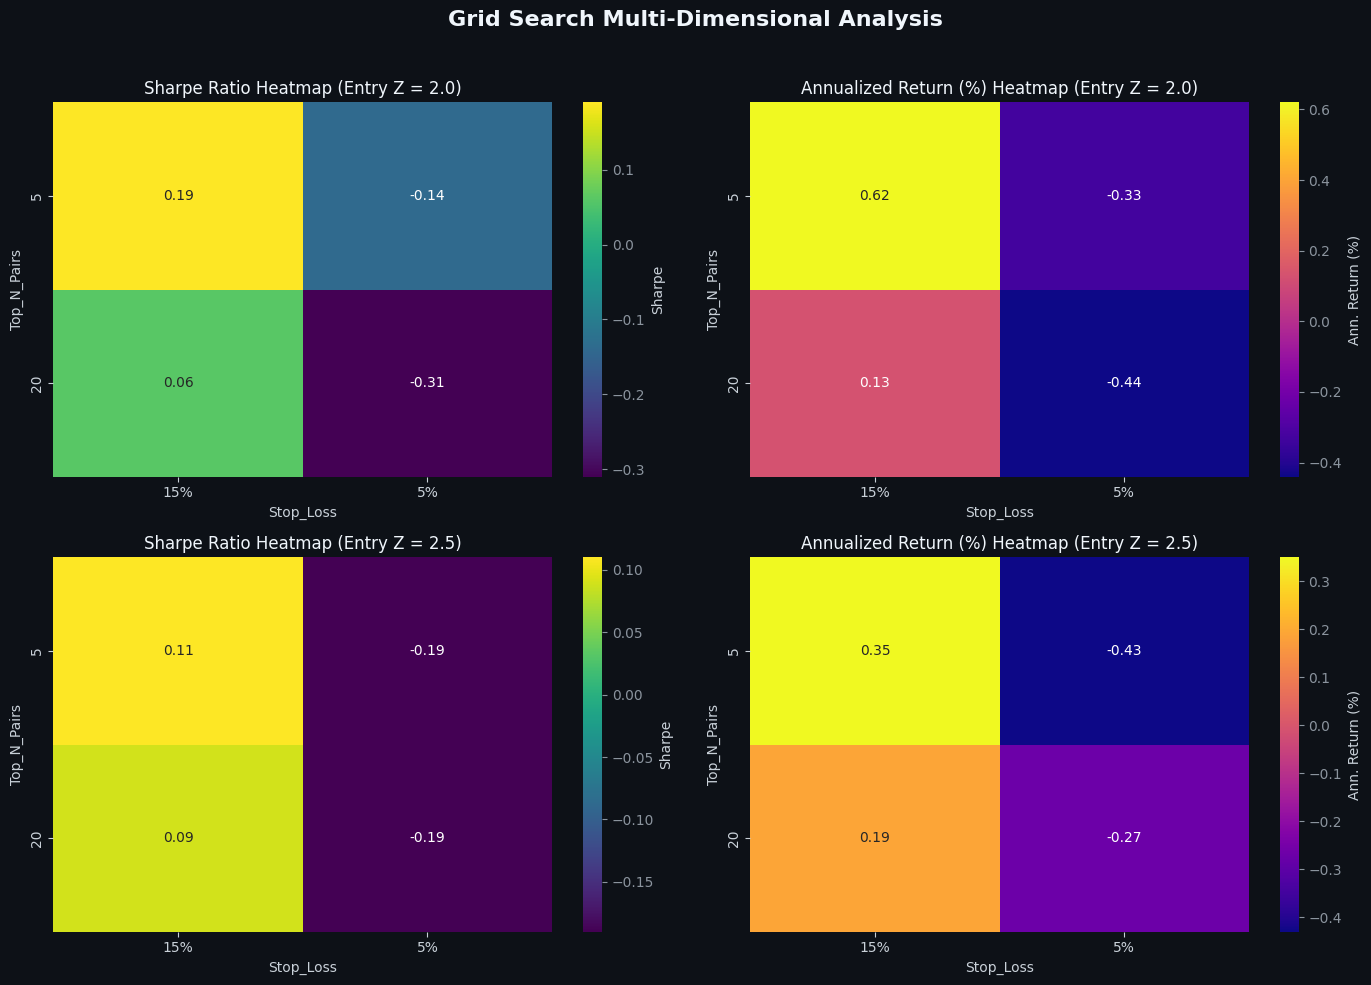

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# 主程式：自動參數網格搜尋 (Grid Search)
# ══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    DB_PATH, TABLE_NAME = r"../data/sp500.db", "daily_prices"
    BACKTEST_START, BACKTEST_END = "2000-01", "2025-12"
    INFO_TABLE_NAME, TICKER_COL_NAME, SECTOR_COL_NAME = "company_info", "ticker", "sector"
    
    TOP_N_LIST = [5, 20]
    STOP_LOSS_LIST = [0.05, 0.15]
    ENTRY_Z_LIST = [2.0, 2.5] 
    
    FORMATION_WINDOW, TRADING_WINDOW, ROLLING_STEP = 252, 126, 21
    EXIT_Z = 0.0 
    
    FEE_RATE = 0.001 
    SLIPPAGE_RATE = 0.001 
    INITIAL_CAPITAL = 10000 
    
    ALLOW_REENTRY = True            
    USE_SECTOR_PAIRING = False       
    
    OUTPUT_DIR = Path(r"../results/SSD_ReEntry")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    processor = DataProcessor(db_path=DB_PATH, table_name=TABLE_NAME)
    
    if USE_SECTOR_PAIRING:
        sector_mapping = processor.load_sector_mapping(INFO_TABLE_NAME, TICKER_COL_NAME, SECTOR_COL_NAME)
    else:
        sector_mapping = {}
        print("ℹ️ 產業分類配對已關閉 (USE_SECTOR_PAIRING = False)，系統將進行全市場全標的配對。")
        
    price_pivot, all_dates, total_days, local_first_trade_idx = processor.prepare_backtest_data(BACKTEST_START, BACKTEST_END, FORMATION_WINDOW)

    max_concurrent = TRADING_WINDOW // ROLLING_STEP
    
    states = {}
    
    for n, sl, ez in itertools.product(TOP_N_LIST, STOP_LOSS_LIST, ENTRY_Z_LIST):
        sub_dir = OUTPUT_DIR / f"Top{n}_SL{int(sl*100)}_EZ{int(ez*10)}"
        perf = Performance(initial_capital=INITIAL_CAPITAL, output_dir=sub_dir)
        perf.set_zscore_params(entry_z=ez, exit_z=EXIT_Z)
        states[(n, sl, ez)] = {
            "perf": perf, 
            "slots": [{"avail_idx": 0, "capital": INITIAL_CAPITAL / max_concurrent} for _ in range(max_concurrent)]
        }

    roll_start_indices = list(range(local_first_trade_idx, total_days - TRADING_WINDOW + 1, ROLLING_STEP))
    print(f"\n🚀 開始進行 Grid Search，共 {len(roll_start_indices)} 期，每期處理 {len(states)} 種參數組合...")

    for roll_idx, trade_start_idx in enumerate(roll_start_indices):
        form_start_idx, form_end_idx = trade_start_idx - FORMATION_WINDOW, trade_start_idx
        trade_end_idx = min(trade_start_idx + TRADING_WINDOW, total_days)

        form_data = price_pivot.iloc[form_start_idx:form_end_idx]
        trade_data = price_pivot.iloc[trade_start_idx:trade_end_idx]
        valid_cols = (form_data.isnull().sum() + trade_data.isnull().sum()) == 0
        form_data, trade_data = form_data.loc[:, valid_cols], trade_data.loc[:, valid_cols]

        if form_data.shape[1] < 2 or trade_data.empty: continue

        trade_start_str, trade_end_str = str(all_dates[trade_start_idx])[:10], str(all_dates[trade_end_idx - 1])[:10]
        form_start_str, form_end_str = str(all_dates[form_start_idx])[:10], str(all_dates[form_end_idx - 1])[:10]
        print(f"  ▶ 處理中：第 {roll_idx+1:02d} 期 (交易: {trade_start_str} ~ {trade_end_str})")

        formation = Formation(form_data, form_start_str, form_end_str, max(TOP_N_LIST), sector_mapping)
        max_selected_pairs = formation.run()

        if max_selected_pairs.empty: continue

        # 產生所有參數組合
        for n, sl, ez in itertools.product(TOP_N_LIST, STOP_LOSS_LIST, ENTRY_Z_LIST):
            selected_pairs = max_selected_pairs.head(n)
            state = states[(n, sl, ez)]
            slots = state["slots"]
            
            # 尋找可用的資金槽位
            free_slots = [i for i, s in enumerate(slots) if s["avail_idx"] <= trade_start_idx]
            if free_slots:
                slot_idx = free_slots[0]
            else:
                slot_idx = min(range(max_concurrent), key=lambda i: slots[i]["avail_idx"])

            current_period_capital = slots[slot_idx]["capital"]
            current_capital_per_pair = current_period_capital / n

            trading = Trading(
                price_df=trade_data,
                selected_pairs=selected_pairs,
                capital_per_pair=current_capital_per_pair,
                fee_rate=FEE_RATE,
                slippage_rate=SLIPPAGE_RATE,
                stop_loss_pct=sl,
                entry_z=ez,
                exit_z=EXIT_Z,
                allow_reentry=ALLOW_REENTRY
            )
            
            trade_log_df, period_daily_delta = trading.run()
            period_pnl = trading.period_pnl if not trade_log_df.empty else 0.0
            
            # 結算當期損益並更新槽位狀態
            slots[slot_idx]["capital"] = max(0, current_period_capital + period_pnl)
            slots[slot_idx]["avail_idx"] = trade_end_idx
            
            state["perf"].add_period(trade_start_str, trade_end_str, trade_log_df, period_daily_delta, current_period_capital, current_capital_per_pair)

    summary_results = []
    print("\n✅ 回測完成！正在產生總結報表...")
    for (n, sl, ez), state in states.items():
        report = state["perf"].generate_report(quiet=True)
        if report:
            report["Top_N_Pairs"] = n
            report["Stop_Loss"] = f"{sl*100:.0f}%"
            report["Entry_Z"] = ez
            summary_results.append(report)

    if not summary_results:
        print("⚠️ 無有效交易紀錄，請檢查資料或參數設定。")
    else:
        summary_df = pd.DataFrame(summary_results)
        cols = ["Entry_Z", "Top_N_Pairs", "Stop_Loss", "Annualized Return (%)", "Sharpe Ratio", "Max Drawdown (%)", "Period Win Rate (%)", "Trade Win Rate (%)", "Total Trades", "Avg Payoff Ratio", "Avg R_EC (%)"]
        summary_df = summary_df[cols].sort_values("Sharpe Ratio", ascending=False)
        summary_df.to_csv(OUTPUT_DIR / "grid_search_summary.csv", index=False)

        plt.rcParams.update({"figure.facecolor": "#0d1117", "axes.facecolor": "#161b22", "text.color": "#c9d1d9"})
        fig, axes = plt.subplots(len(ENTRY_Z_LIST), 2, figsize=(14, 5 * len(ENTRY_Z_LIST)), squeeze=False)
        fig.patch.set_facecolor("#0d1117")

        for idx, ez in enumerate(ENTRY_Z_LIST):
            df_sub = summary_df[summary_df["Entry_Z"] == ez]
            if df_sub.empty: continue
            
            pivot_sharpe = df_sub.pivot(index="Top_N_Pairs", columns="Stop_Loss", values="Sharpe Ratio")
            pivot_ann_ret = df_sub.pivot(index="Top_N_Pairs", columns="Stop_Loss", values="Annualized Return (%)")

            sns.heatmap(pivot_sharpe, annot=True, cmap="viridis", ax=axes[idx, 0], cbar_kws={'label': 'Sharpe'}, fmt=".2f")
            axes[idx, 0].set_title(f"Sharpe Ratio Heatmap (Entry Z = {ez})", color="#f0f6fc")
            axes[idx, 0].tick_params(colors="#c9d1d9")

            sns.heatmap(pivot_ann_ret, annot=True, cmap="plasma", ax=axes[idx, 1], cbar_kws={'label': 'Ann. Return (%)'}, fmt=".2f")
            axes[idx, 1].set_title(f"Annualized Return (%) Heatmap (Entry Z = {ez})", color="#f0f6fc")
            axes[idx, 1].tick_params(colors="#c9d1d9")

        plt.suptitle(f"Grid Search Multi-Dimensional Analysis", color="#f0f6fc", fontsize=16, fontweight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        heatmap_file = OUTPUT_DIR / "grid_search_heatmap.png"
        fig.savefig(heatmap_file, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        
        plt.show()